In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [4]:
# ============================================================
# 2. LOAD THE DATA
# ============================================================

from google.colab import files

# Upload the dataset from your computer
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("superstore.csv")

# Display the first five rows
display(df.head())

Saving superstore.csv to superstore (1).csv


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [5]:
# ============================================================
# 3. UNDERSTAND THE DATA
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Dataset shape: (51290, 27)

Column names:
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', '记录数', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']

Data types:
Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
记录数                 int64
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       o

In [6]:
# ============================================================
# 4. DATA QUALITY CHECK
# ============================================================

# Check for missing values
print("Missing values:")
display(df.isnull().sum())

# Check for duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Missing values:


,0
Category,0
City,0
Country,0
Customer.ID,0
Customer.Name,0
Discount,0
Market,0
记录数,0
Order.Date,0
Order.ID,0


Number of duplicate rows: 0


In [7]:
# ============================================================
# 5. BASIC BUSINESS KPIs
# ============================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_transactions = df.shape[0]
average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()

print("======================================")
print("        RETAIL BUSINESS KPIs")
print("======================================")

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Transactions: {total_transactions:,}")
print(f"Average Sales per Transaction: ${average_sales:,.2f}")
print(f"Average Profit per Transaction: ${average_profit:,.2f}")

        RETAIL BUSINESS KPIs
Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Total Transactions: 51,290
Average Sales per Transaction: $246.50
Average Profit per Transaction: $28.61


In [8]:
# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================

display(
    df[
        ["Sales", "Quantity", "Discount", "Profit"]
    ].describe()
)

,Sales,Quantity,Discount,Profit
count,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.610982
std,487.567175,2.278766,0.212280,174.340972
min,0.000000,1.000000,0.000000,-6599.978000
25%,31.000000,2.000000,0.000000,0.000000
50%,85.000000,3.000000,0.000000,9.240000
75%,251.000000,5.000000,0.200000,36.810000
max,22638.000000,14.000000,0.850000,8399.976000


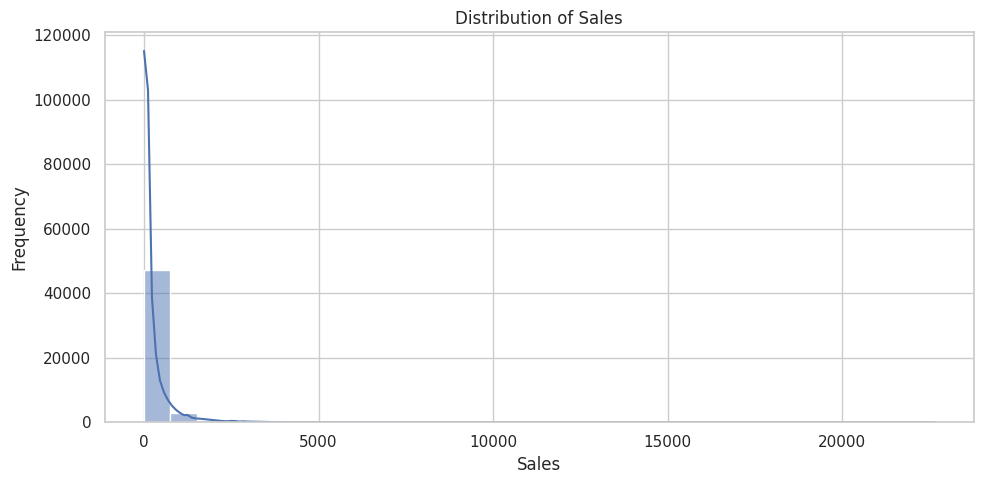

In [9]:
# ============================================================
# 7. SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

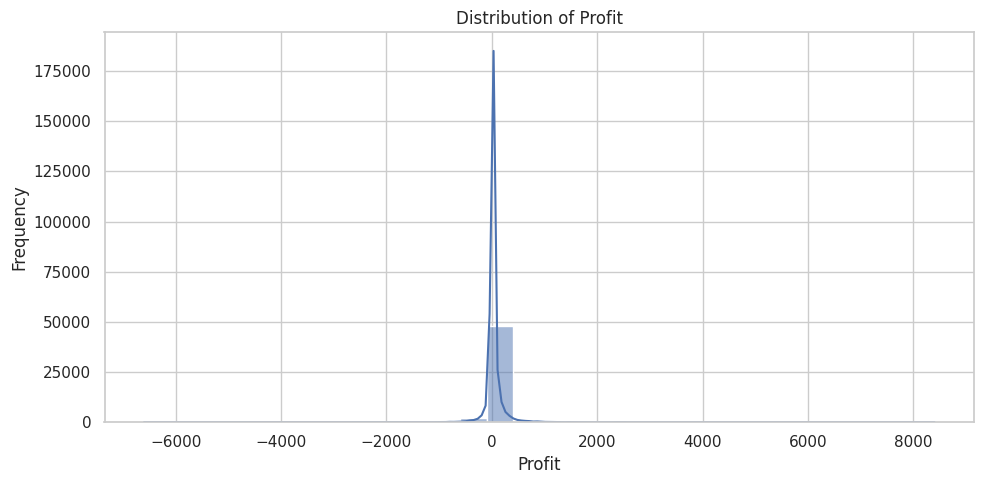

In [10]:
# ============================================================
# 8. PROFIT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Profit",
    bins=30,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 9. SALES & PROFIT BY CATEGORY
# ============================================================

category_performance = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Transactions=("Sales", "count")
      )
      .sort_values("Sales", ascending=False)
)

print("Performance by Product Category:")

display(category_performance)

Performance by Product Category:


,Sales,Profit,Transactions
Category,,,
Technology,4744691,663778.73318,10141
Furniture,4110884,285204.72380,9876
Office Supplies,3787330,518473.83430,31273


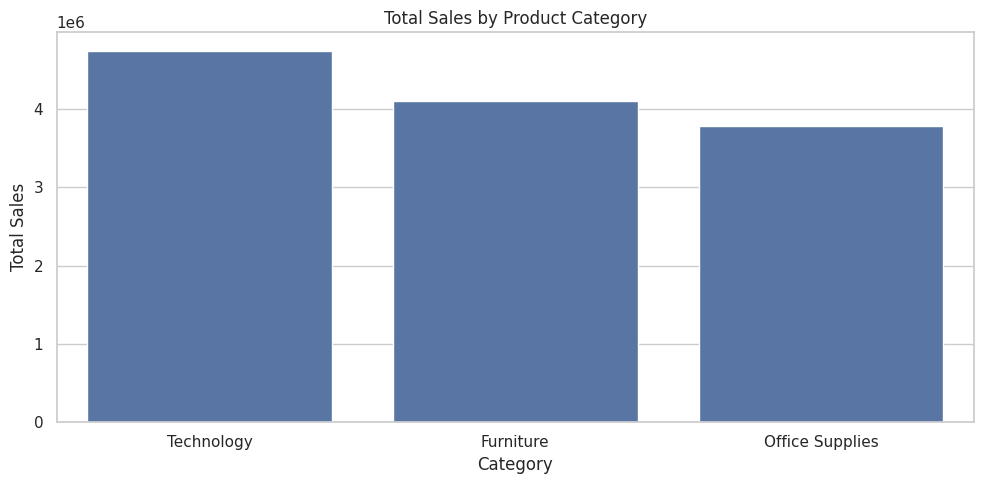

In [12]:
# ============================================================
# 10. SALES BY CATEGORY
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_performance.reset_index(),
    x="Category",
    y="Sales"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

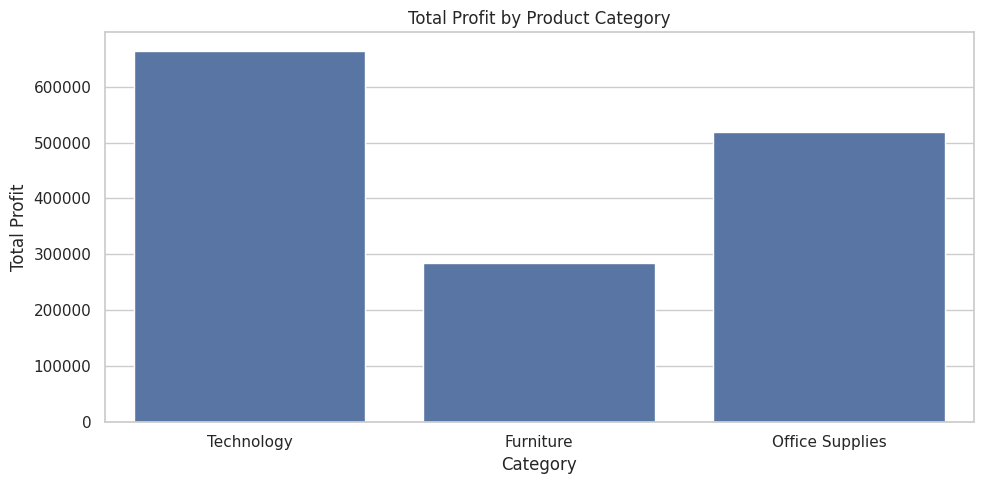

In [13]:
# ============================================================
# 11. PROFIT BY CATEGORY
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_performance.reset_index(),
    x="Category",
    y="Profit"
)

plt.title("Total Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 12. SALES & PROFIT BY SUB-CATEGORY
# ============================================================

sub_category_performance = (
    df.groupby("Sub.Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .sort_values("Sales", ascending=False)
)

print("Performance by Sub-Category:")

display(sub_category_performance)

Performance by Sub-Category:


,Sales,Profit
Sub.Category,,
Phones,1706874,216717.00580
Copiers,1509439,258567.54818
Chairs,1501682,140396.26750
Bookcases,1466559,161924.41950
Storage,1127124,108461.48980
Appliances,1011081,141680.58940
Machines,779071,58867.87300
Tables,757034,-64083.38870
Accessories,749307,129626.30620


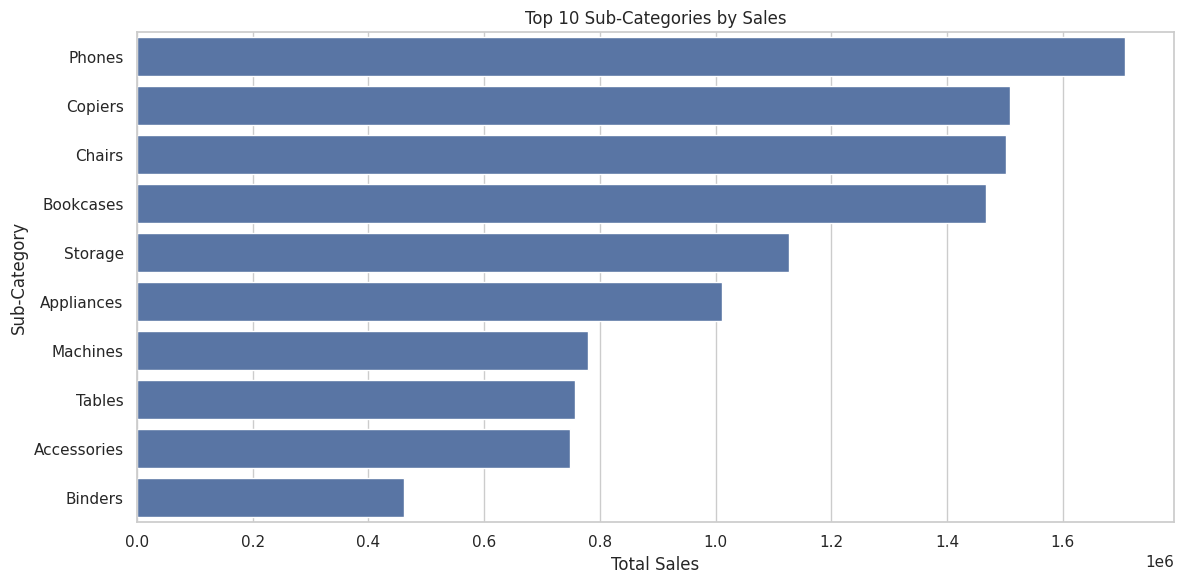

In [15]:
# ============================================================
# 13. TOP 10 SUB-CATEGORIES BY SALES
# ============================================================

top_subcategories = (
    sub_category_performance
    .sort_values("Sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_subcategories.reset_index(),
    x="Sales",
    y="Sub.Category"
)

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

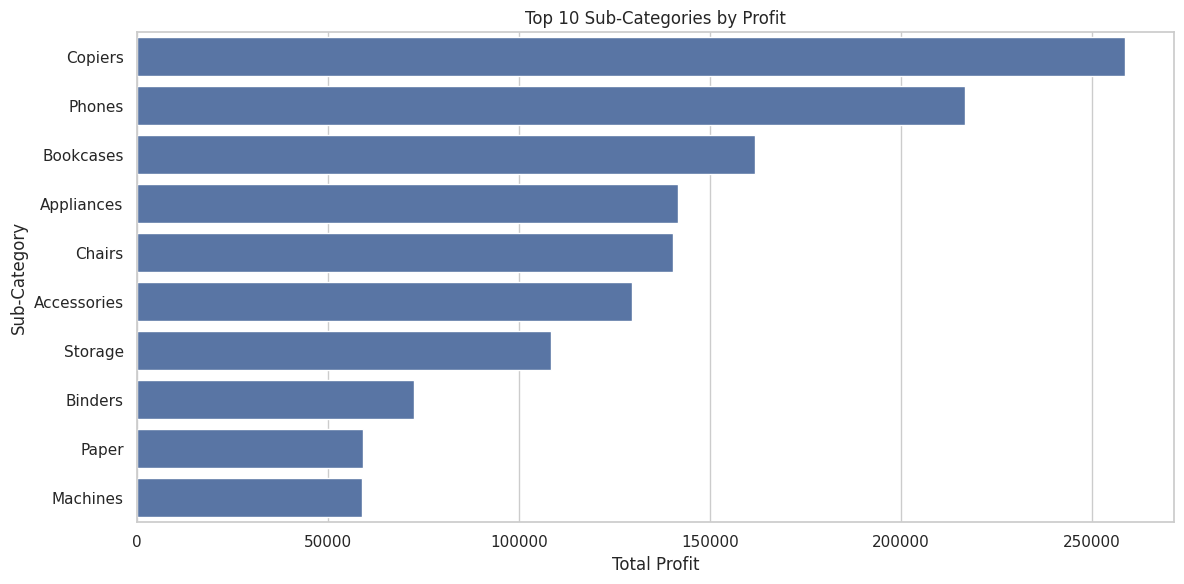

In [16]:
# ============================================================
# 14. TOP 10 SUB-CATEGORIES BY PROFIT
# ============================================================

top_profit_subcategories = (
    sub_category_performance
    .sort_values("Profit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_profit_subcategories.reset_index(),
    x="Profit",
    y="Sub.Category"
)

plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 15. CUSTOMER SEGMENT ANALYSIS
# ============================================================

segment_performance = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Transactions=("Sales", "count")
      )
      .sort_values("Sales", ascending=False)
)

print("Performance by Customer Segment:")

display(segment_performance)

Performance by Customer Segment:


,Sales,Profit,Transactions
Segment,,,
Consumer,6508141,749239.78206,26518
Corporate,3824808,441208.32866,15429
Home Office,2309956,277009.18056,9343


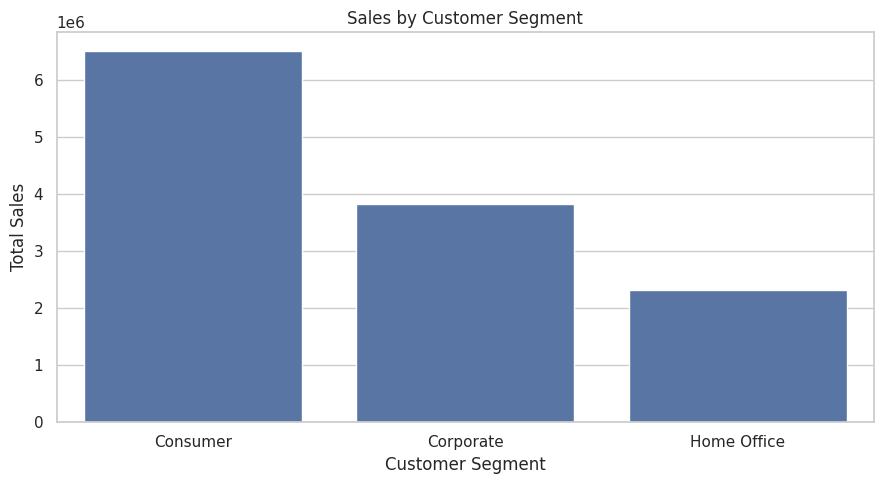

In [18]:
# ============================================================
# 16. SALES BY CUSTOMER SEGMENT
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=segment_performance.reset_index(),
    x="Segment",
    y="Sales"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

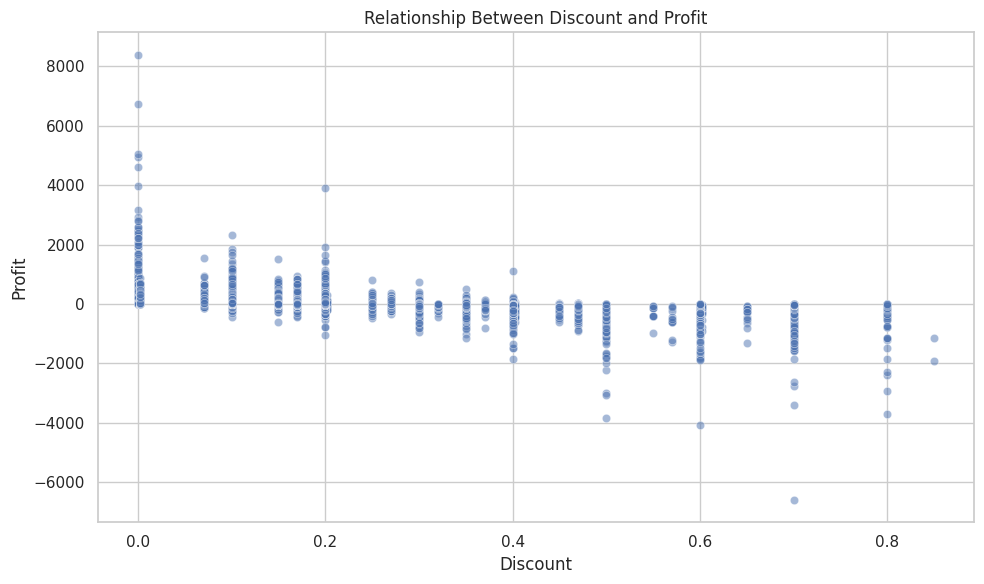

In [19]:
# ============================================================
# 17. DISCOUNT VS PROFIT
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

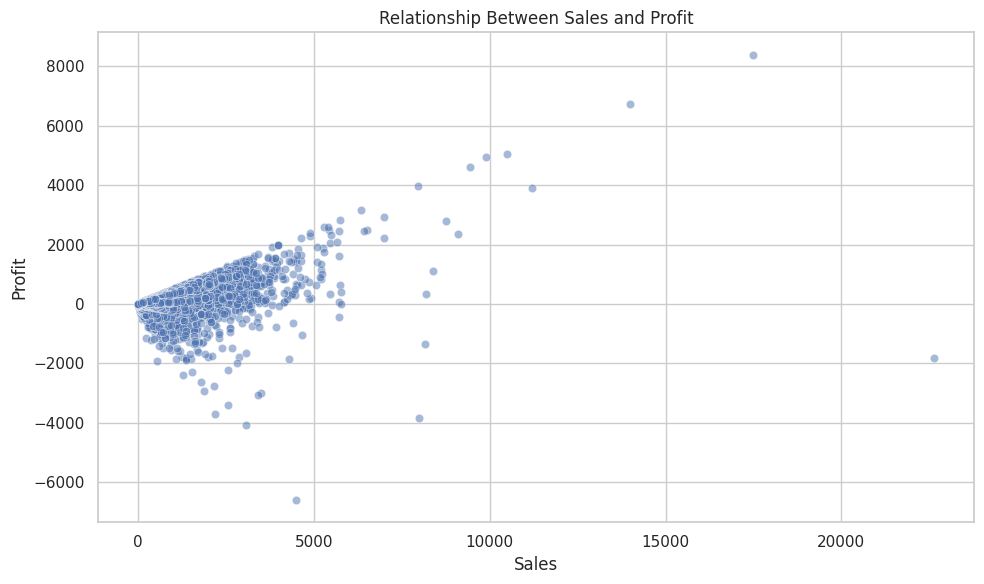

In [20]:
# ============================================================
# 18. SALES VS PROFIT
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Sales and Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

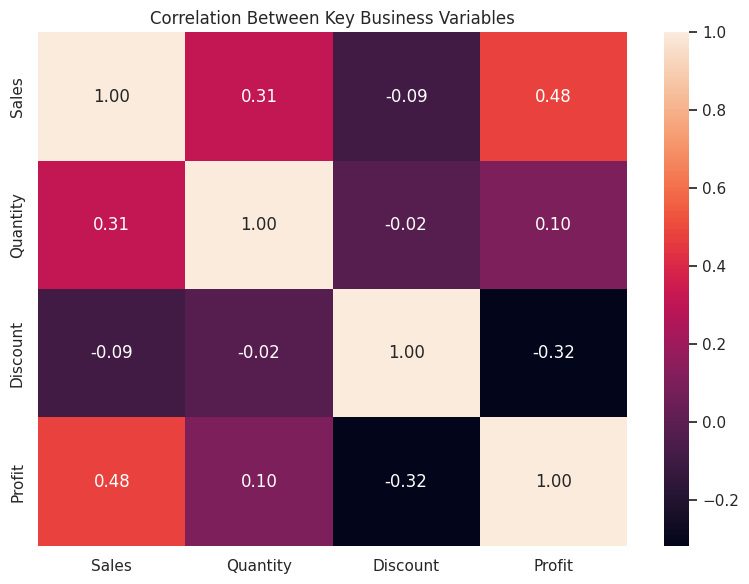

In [21]:
# ============================================================
# 19. CORRELATION ANALYSIS
# ============================================================

numerical_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Key Business Variables")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 20. TOP 10 TRANSACTIONS BY SALES
# ============================================================

high_sales = df.nlargest(10, "Sales")

display(
    high_sales[
        [
            "Category",
            "Sub.Category",
            "Segment",
            "Sales",
            "Quantity",
            "Discount",
            "Profit"
        ]
    ]
)

,Category,Sub.Category,Segment,Sales,Quantity,Discount,Profit
47257,Technology,Machines,Home Office,22638,6,0.5,-1811.0784
27727,Technology,Copiers,Corporate,17500,5,0.0,8399.9760
28327,Technology,Copiers,Consumer,14000,4,0.0,6719.9808
48073,Technology,Copiers,Home Office,11200,4,0.2,3919.9888
27524,Technology,Copiers,Consumer,10500,3,0.0,5039.9856
3092,Office Supplies,Binders,Consumer,9893,13,0.0,4946.3700
2722,Office Supplies,Binders,Consumer,9450,5,0.0,4630.4755
27459,Technology,Machines,Corporate,9100,7,0.0,2365.9818
28193,Technology,Machines,Consumer,8750,5,0.0,2799.9840
46605,Technology,Copiers,Consumer,8400,4,0.4,1119.9968


In [23]:
# ============================================================
# 21. LOSS-MAKING TRANSACTIONS
# ============================================================

loss_making = df[df["Profit"] < 0]

print(
    "Number of Loss-Making Transactions:",
    len(loss_making)
)

print(
    "Total Loss:",
    f"${loss_making['Profit'].sum():,.2f}"
)

Number of Loss-Making Transactions: 12544
Total Loss: $-920,646.16


In [24]:
# ============================================================
# 22. LOSS-MAKING SUB-CATEGORIES
# ============================================================

loss_by_subcategory = (
    df.groupby("Sub.Category")["Profit"]
      .sum()
      .sort_values()
)

print("Sub-Categories with Lowest Profit:")

display(
    loss_by_subcategory.head(10)
)

Sub-Categories with Lowest Profit:


,Profit
Sub.Category,
Tables,-64083.3887
Fasteners,11525.4241
Labels,15010.5120
Supplies,22583.2631
Envelopes,29601.1163
Furnishings,46967.4255
Art,57953.9109
Machines,58867.8730
Paper,59207.6827


In [25]:
# ============================================================
# 23. BUSINESS PERFORMANCE SUMMARY
# ============================================================

best_sales_category = category_performance["Sales"].idxmax()

best_profit_category = category_performance["Profit"].idxmax()

best_sales_subcategory = sub_category_performance["Sales"].idxmax()

best_profit_subcategory = sub_category_performance["Profit"].idxmax()

best_segment = segment_performance["Sales"].idxmax()

print("======================================")
print("       BUSINESS PERFORMANCE SUMMARY")
print("======================================")

print(f"Highest Sales Category: {best_sales_category}")

print(f"Highest Profit Category: {best_profit_category}")

print(f"Highest Sales Sub-Category: {best_sales_subcategory}")

print(f"Highest Profit Sub-Category: {best_profit_subcategory}")

print(f"Highest Sales Customer Segment: {best_segment}")

       BUSINESS PERFORMANCE SUMMARY
Highest Sales Category: Technology
Highest Profit Category: Technology
Highest Sales Sub-Category: Phones
Highest Profit Sub-Category: Copiers
Highest Sales Customer Segment: Consumer


In [26]:
# ============================================================
# 24. SIMPLE SALES PREDICTION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select features
features = [
    "Quantity",
    "Discount"
]

X = df[features]
y = df["Sales"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

print("Sales prediction model trained successfully.")

Sales prediction model trained successfully.


In [27]:
# ============================================================
# 25. MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("======================================")
print("       SALES PREDICTION RESULTS")
print("======================================")

print(f"Mean Absolute Error: ${mae:,.2f}")

print(f"R-squared: {r2:.2f}")

       SALES PREDICTION RESULTS
Mean Absolute Error: $241.98
R-squared: 0.09


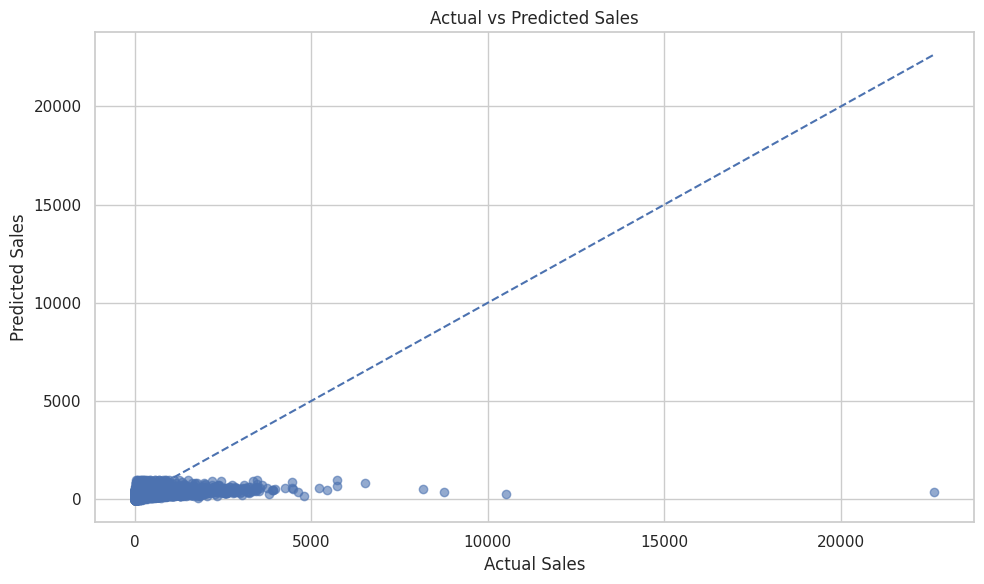

In [28]:
# ============================================================
# 26. ACTUAL VS PREDICTED SALES
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# 27. FINAL BUSINESS INSIGHTS
# ============================================================

print("""
======================================
          FINAL BUSINESS INSIGHTS
======================================

The analysis provides an overview of sales,
profitability, product performance and
customer segment performance.

Key areas identified for business review include:

• Highest-performing product categories
• Highest-performing sub-categories
• Most valuable customer segments
• Loss-making transactions and product areas
• Relationship between discounts and profit
• Relationship between sales and profit
• Areas requiring further investigation

The analysis can support business decisions related
to product performance, pricing, discount strategies,
and customer segmentation.

The predictive model provides a simple demonstration
of using transaction-level variables to estimate Sales.

Model results should be interpreted carefully because
the available variables may not capture all factors
that influence real-world sales.
""")


          FINAL BUSINESS INSIGHTS

The analysis provides an overview of sales,
profitability, product performance and
customer segment performance.

Key areas identified for business review include:

• Highest-performing product categories
• Highest-performing sub-categories
• Most valuable customer segments
• Loss-making transactions and product areas
• Relationship between discounts and profit
• Relationship between sales and profit
• Areas requiring further investigation

The analysis can support business decisions related
to product performance, pricing, discount strategies,
and customer segmentation.

The predictive model provides a simple demonstration
of using transaction-level variables to estimate Sales.

Model results should be interpreted carefully because
the available variables may not capture all factors
that influence real-world sales.



In [30]:
# ============================================================
# 28. CONCLUSION
# ============================================================

print("""
======================================
              CONCLUSION
======================================

This project followed an end-to-end Data Analysis
workflow:

1. Data Loading
2. Data Understanding
3. Data Quality Assessment
4. Exploratory Data Analysis
5. Business Performance Analysis
6. Data Visualization
7. Correlation Analysis
8. Business Insights
9. Basic Predictive Analysis
10. Business Conclusion

The project demonstrates how Python can be used
to transform raw retail data into meaningful
business information and support data-driven
decision-making.
""")


              CONCLUSION

This project followed an end-to-end Data Analysis
workflow:

1. Data Loading
2. Data Understanding
3. Data Quality Assessment
4. Exploratory Data Analysis
5. Business Performance Analysis
6. Data Visualization
7. Correlation Analysis
8. Business Insights
9. Basic Predictive Analysis
10. Business Conclusion

The project demonstrates how Python can be used
to transform raw retail data into meaningful
business information and support data-driven
decision-making.

